# ISLES 2022 UNet


In [1]:
!pip install -q 'monai[all]'

In [ ]:
# from IPython.display import clear_output
# # Need to do this every time I spin the notebook up
# !pip install -qr requirements.txt
# !pip install -q --upgrade torch torchvision
# clear_output()

# Imports

In [4]:
import os
import glob
from pathlib import Path

import numpy as np
import torch
from torch.nn import functional as F
from torch.optim.lr_scheduler import StepLR
import matplotlib.pyplot as plt

from monai.utils import first, set_determinism
from monai.transforms import (
    MapTransform,
    AsDiscrete,
    AsDiscreted,
    EnsureChannelFirstd,
    Compose,
    CropForegroundd,
    LoadImaged,
    Orientationd,
    RandCropByPosNegLabeld,
    Rotated,
    SaveImaged,
    ScaleIntensityRanged,
    Spacingd,
    EnsureTyped,
    EnsureType,
    Invertd,
    Rotate90d,
)

from monai.handlers.utils import from_engine
from monai.networks.nets import UNet, UNETR
from monai.networks.layers import Norm
from monai.metrics import DiceMetric
from monai.losses import DiceLoss, DiceCELoss
from monai.inferers import sliding_window_inference
from monai.data import CacheDataset, DataLoader, Dataset, decollate_batch
from monai.config import print_config
from monai.apps import download_and_extract

# Change Device to Cuda

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print()

#Additional Info when using cuda
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print(torch.cuda.get_device_properties(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

Using device: cuda

Tesla T4
_CudaDeviceProperties(name='Tesla T4', major=7, minor=5, total_memory=15109MB, multi_processor_count=40)
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


# Load Data

In [6]:
def get_paths(mask):
    data_dir = os.path.join(os.getcwd(), 'data/train')
    tmp = []
    for path in Path(data_dir).rglob(mask):
        tmp.append(path.resolve())
    return tmp

In [7]:
training_dir = os.path.join(os.getcwd(), 'weights')

image_paths = get_paths('*T1w*')
label_paths = get_paths('*mask*')

# To ensure I am not pulling in the training set with no mask/labels
assert(len(image_paths) == len(label_paths))
data_length = len(image_paths)

In [8]:
data_dicts = [
    {"image": image_name, "label": label_name}
    for image_name, label_name in zip(image_paths, label_paths)
]

# Because, why not? 
assert(len(data_dicts) == data_length)

In [9]:
from torch.utils.data import random_split

# Create train and validation sets
data_len = len(data_dicts)
val_len = int(data_len / 10)
train_len = data_len - val_len
train_files, val_files = random_split(data_dicts, [train_len, val_len])

In [10]:
train_set = []
val_set = []
for i in range(100):
    train_set.append(train_files[i])

for i in range(10):
    val_set.append(val_files[i])

if len(train_files) != 100:
    train_files = train_set
    val_files = val_set


In [11]:
print(len(train_files))
print(len(val_files))

100
10


# Create Transforms using Monai

In [12]:
train_transforms = Compose(
    [
        LoadImaged(keys=["image", "label"]), # Load image file or files from provided path based on reader.
        EnsureChannelFirstd(keys=["image", "label"]), #adds a channel dimension if the data doesn't have one ... torch.Size([1, ...]) = torch.Size([1, 1, ...
        Orientationd(keys=["image", "label"], axcodes="LPS"),
        Rotate90d(keys=["image", "label"], k=1, spatial_axes=(0,2)), # rotate data so it looks like it should do? ... doesn't feel right when viewing otherwise
        ScaleIntensityRanged(
            keys=["image"], a_min=0.0, a_max=302.0,
            b_min=0.0, b_max=1.0, clip=True,
        ),
        RandCropByPosNegLabeld(
            keys=["image", "label"],
            label_key="label",
            spatial_size=(96, 96, 96),   # provides size of each image within the batch
            pos=1,      # pos / (pos + neg) = ratio of postivie and negative samples picked... 
            neg=1,      # with pos = neg = 1, ratio = 0.5 so it picks equal pos (stoke) and neg (no stroke) for sample.
            num_samples=4,   # number of smaller volumes to create from the original volume
            image_key="image",
            image_threshold=0,
        ),
        EnsureTyped(keys=["image", "label"]), # converts the data to a pytorch tensor
    ]
)
# Same as above but without the cropping
val_transforms = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        Orientationd(keys=["image", "label"], axcodes="LPS"),
        Rotate90d(keys=["image", "label"], k=1, spatial_axes=(0,2)), 
        ScaleIntensityRanged(
            keys=["image"], a_min=0.0, a_max=302.0,
            b_min=0.0, b_max=1.0, clip=True,
        ),
        EnsureTyped(keys=["image", "label"]),
    ]
)

In [13]:
# check_ds = Dataset(data=val_files, transform=val_transforms)
# check_loader = DataLoader(check_ds, batch_size=1)
# check_data = first(check_loader)
# image, label = (check_data["image"], check_data["label"])
# print(f"image shape: {image.shape}, label shape: {label.shape}")

In [14]:
# check_ds = Dataset(data=train_files, transform=train_transforms)
# check_loader = DataLoader(check_ds, batch_size=1)
# check_data = first(check_loader)
# image, label = (check_data["image"], check_data["label"])
# print(f"image shape: {image.shape}, label shape: {label.shape}")

In [15]:
# # Does the data look right?
# i = 60
# batch = 0
# plt.figure("check", (12, 6))
# plt.subplot(1, 2, 1)
# plt.title("image")
# plt.imshow(image[0][0][i,:,:], cmap="gray")
# plt.subplot(1, 2, 2)
# plt.title("label")
# plt.imshow(label[0][0][i,:,:])
# plt.show()

In [18]:
if device.type == 'cuda':
    train_ds = CacheDataset(
        data=train_files, 
        transform=train_transforms,
        cache_rate=1.0, 
        num_workers=4
    )
    metrics_train_ds = CacheDataset(
        data=train_files, 
        transform=val_transforms,
        cache_rate=1.0,
        num_workers=4
    )

    val_ds = CacheDataset(
        data=val_files, 
        transform=val_transforms, 
        cache_rate=1.0, 
        num_workers=4
    )
    metrics_val_ds = CacheDataset(
        data=val_files, 
        transform=train_transforms,
        cache_rate=1.0,
        num_workers=4
    )
else:
    train_ds = Dataset(data=train_files, transform=train_transforms)
    val_ds = Dataset(data=val_files, transform=val_transforms)
    metrics_val_ds = Dataset(data=val_files, transform=train_transforms)
    metrics_train_ds = Dataset(data=train_files, transform=val_transforms)
    
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=4)
val_loader = DataLoader(val_ds, batch_size=1, num_workers=4)
metrics_train_loader = DataLoader(metrics_train_ds, batch_size=4, num_workers=4)
metrics_val_loader = DataLoader(metrics_val_ds, batch_size=1, num_workers=4)

Loading dataset: 100%|██████████| 10/10 [00:02<00:00,  4.21it/s]


In [19]:
model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=2,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=0,
    norm=Norm.BATCH,
    dropout=0.25,
).to(device)

# model = AttentionUnet(
#     spatial_dims=3,
#     in_channels=1,
#     out_channels=2,
#     channels=(16, 32, 64, 128, 256),
#     strides=(2, 2, 2, 2),
#     dropout=0.25,
# ).to(device)

# model = UNETR(
#     in_channels=1,
#     out_channels=14,
#     img_size=(96, 96, 96),
#     feature_size=16,
#     hidden_size=768,
#     mlp_dim=3072,
#     num_heads=12,
#     pos_embed="perceptron",
#     norm_name="instance",
#     res_block=True,
#     dropout_rate=0.25,
# ).to(device)

In [ ]:
# model.load_state_dict(torch.load(
#     os.path.join(training_dir, "best_metric_model.pth")))

In [ ]:
# positive_total_count = 0 # this is where the label is 1, stroke.
# negative_total_count = 0 # this is where the label is 0, not stroke

# # calculating the amount of 1's and 0's in all the labels
# for batch_data in train_loader:
#         inputs, labels = (batch_data["image"], batch_data["label"])
#         count = labels.unique(return_counts=True)
#         positive_total_count += int(count[1][1])
#         negative_total_count += int(count[1][0])

In [ ]:
# print('percentage of postitive (stroke) in labels:')
# print(positive_total_count / negative_total_count * 100)

# total = positive_total_count + negative_total_count
# # total / numOfClasses* Number in class
# nostroke_weight = total / (2 * negative_total_count)
# stroke_weight = total / (2 * positive_total_count)

# print(nostroke_weight)
# print(stroke_weight)

# weights = [nostroke_weight, stroke_weight]

In [22]:
# # average weight throughout entire label set
# weights = torch.tensor([0.5075946593908832, 33.41786861437203])
# weights = torch.tensor([0.5, 32]) # rounded from above
# loss_function = DiceCELoss(to_onehot_y=True, softmax=True, ce_weight=weights.to(device))

loss_function = DiceLoss(to_onehot_y=True, softmax=True)
optimizer = torch.optim.Adam(model.parameters(), 1e-4) 
dice_metric = DiceMetric(include_background=False, reduction="mean")
# scheduler = StepLR(optimiser, step_size=30, gamma=0.01)

In [23]:
max_epochs = 50
val_interval = 2
best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
val_epoch_loss_values = []
train_metric_values = []
metric_values = []
post_pred = Compose([EnsureType(), AsDiscrete(argmax=True, to_onehot=2)])
post_label = Compose([EnsureType(), AsDiscrete(to_onehot=2)])

for epoch in range(max_epochs):
    print("-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0
    for batch_data in train_loader:
        step += 1
        inputs, labels = (
            batch_data["image"].to(device),
            batch_data["label"].to(device),
        )
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")
    step = 0
    val_epoch_loss = 0
    for batch_data in metrics_val_loader:
        step += 1
        inputs, labels = (
            batch_data["image"].to(device),
            batch_data["label"].to(device),
        )
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        val_epoch_loss += loss.item()
    val_epoch_loss /= step
    val_epoch_loss_values.append(val_epoch_loss)
    if (epoch + 1) % val_interval == 0:
        model.eval()
        with torch.no_grad():
            for val_data in val_loader:
                val_inputs, val_labels = (
                    val_data["image"].to(device),
                    val_data["label"].to(device),
                )
                roi_size = (160, 160, 160)
                sw_batch_size = 4
                val_outputs = sliding_window_inference(
                    val_inputs, roi_size, sw_batch_size, model)
                val_outputs = [post_pred(i) for i in decollate_batch(val_outputs)]
                val_labels = [post_label(i) for i in decollate_batch(val_labels)]
                # compute metric for current iteration
                dice_metric(y_pred=val_outputs, y=val_labels)

            # aggregate the final mean dice result
            metric = dice_metric.aggregate().item()
            # reset the status for next validation round
            dice_metric.reset()
            metric_values.append(metric)
            
            for train_data in metrics_train_loader:
                train_inputs, train_labels = (
                    train_data["image"].to(device),
                    train_data["label"].to(device),
                )
                roi_size = (160, 160, 160)
                sw_batch_size = 4
                train_outputs = sliding_window_inference(
                    train_inputs, roi_size, sw_batch_size, model)
                train_outputs = [post_pred(i) for i in decollate_batch(train_outputs)]
                train_labels = [post_label(i) for i in decollate_batch(train_labels)]
                dice_metric(y_pred=train_outputs, y=train_labels)
            train_metric = dice_metric.aggregate().item()
            dice_metric.reset()        
            train_metric_values.append(train_metric)
            
            if metric > best_metric:
                best_metric = metric
                best_metric_epoch = epoch + 1
                torch.save(model.state_dict(), os.path.join(
                    training_dir, "best_metric_model.pth"))
                print("saved new best metric model")
            print(
                f"current epoch: {epoch + 1} current mean dice: {metric:.4f}"
                f"\nbest mean dice: {best_metric:.4f} "
                f"at epoch: {best_metric_epoch}"
            )  
#     scheduler.step()

----------
epoch 1/50
epoch 1 average loss: 0.6125
----------
epoch 2/50
epoch 2 average loss: 0.5972
saved new best metric model
current epoch: 2 current mean dice: 0.0034
best mean dice: 0.0034 at epoch: 2
----------
epoch 3/50
epoch 3 average loss: 0.5856
----------
epoch 4/50
epoch 4 average loss: 0.5740
current epoch: 4 current mean dice: 0.0026
best mean dice: 0.0034 at epoch: 2
----------
epoch 5/50
epoch 5 average loss: 0.5632
----------
epoch 6/50
epoch 6 average loss: 0.5525
saved new best metric model
current epoch: 6 current mean dice: 0.0317
best mean dice: 0.0317 at epoch: 6
----------
epoch 7/50
epoch 7 average loss: 0.5455
----------
epoch 8/50
epoch 8 average loss: 0.5370
current epoch: 8 current mean dice: 0.0274
best mean dice: 0.0317 at epoch: 6
----------
epoch 9/50
epoch 9 average loss: 0.5302
----------
epoch 10/50
epoch 10 average loss: 0.5274
saved new best metric model
current epoch: 10 current mean dice: 0.0340
best mean dice: 0.0340 at epoch: 10
----------
e

In [24]:
print(
    f"train completed, best_metric: {best_metric:.4f} "
    f"at epoch: {best_metric_epoch}")

train completed, best_metric: 0.1507 at epoch: 50


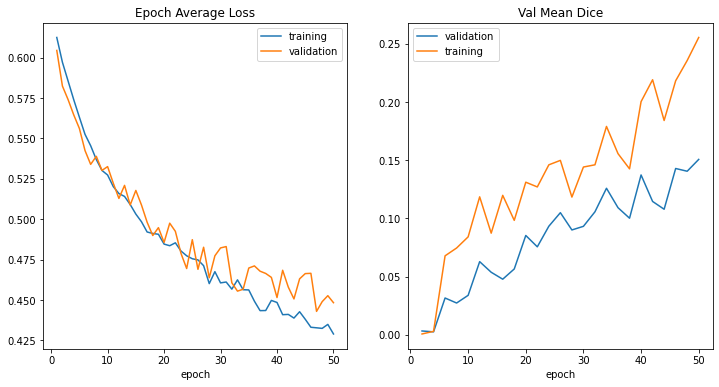

In [25]:
plt.figure("train", (12, 6))
plt.subplot(1, 2, 1)
plt.title("Epoch Average Loss")
x = [i + 1 for i in range(len(epoch_loss_values))]
y = epoch_loss_values
z = val_epoch_loss_values
plt.xlabel("epoch")
plt.plot(x, y, label = "training")
plt.plot(x, z, label = "validation")
plt.legend()
plt.subplot(1, 2, 2)
plt.title("Val Mean Dice")
x = [val_interval * (i + 1) for i in range(len(metric_values))]
y = metric_values
z = train_metric_values
plt.xlabel("epoch")
plt.plot(x, y, label = "validation")
plt.plot(x, z, label = "training")
plt.legend()
# plt.savefig('figures.png')
plt.show()

In [ ]:
model.load_state_dict(torch.load(
    os.path.join(training_dir, "best_metric_model.pth")))
model.eval()
with torch.no_grad():
    for i, val_data in enumerate(val_loader):
        roi_size = (160, 160, 160)
        sw_batch_size = 4
        val_outputs = sliding_window_inference(
            val_data["image"].to(device), roi_size, sw_batch_size, model
        )
        # plot the slice [:, :, 80]
        plt.figure("check", (18, 6))
        plt.subplot(1, 3, 1)
        plt.title(f"image {i}")
        plt.imshow(val_data["image"][0, 0, 75, :, :], cmap="gray")
        plt.subplot(1, 3, 2)
        plt.title(f"label {i}")
        plt.imshow(val_data["label"][0, 0, 75, :, :])
        plt.subplot(1, 3, 3)
        plt.title(f"output {i}")
        plt.imshow(torch.argmax(
            val_outputs, dim=1).detach().cpu()[0, 75, :, :])
        plt.savefig('scans.png')
        plt.show()
        if i == 2:
            break
    